In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


plt.rcParams['figure.figsize'] = (15, 10)

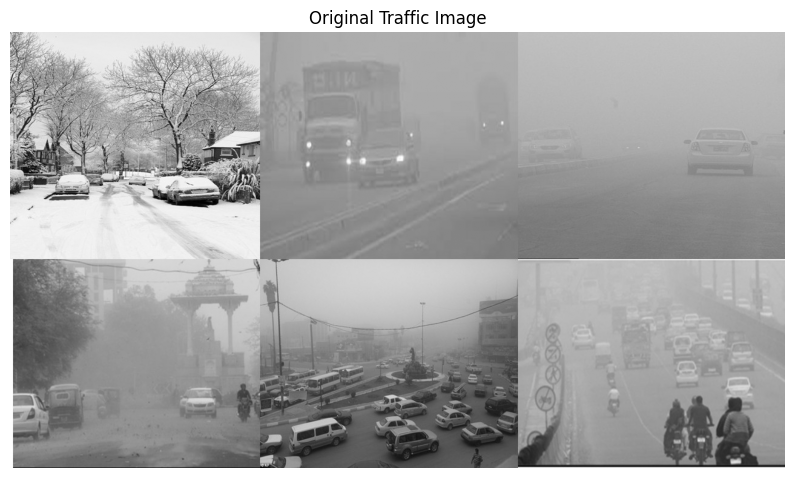

Image Shape: (720, 1280)


In [18]:

img = cv2.imread('traffic.jpg', cv2.IMREAD_GRAYSCALE)


plt.figure(figsize=(10, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Traffic Image')
plt.axis('off')
plt.show()

print(f"Image Shape: {img.shape}")

## 1. Sobel Edge Detection 

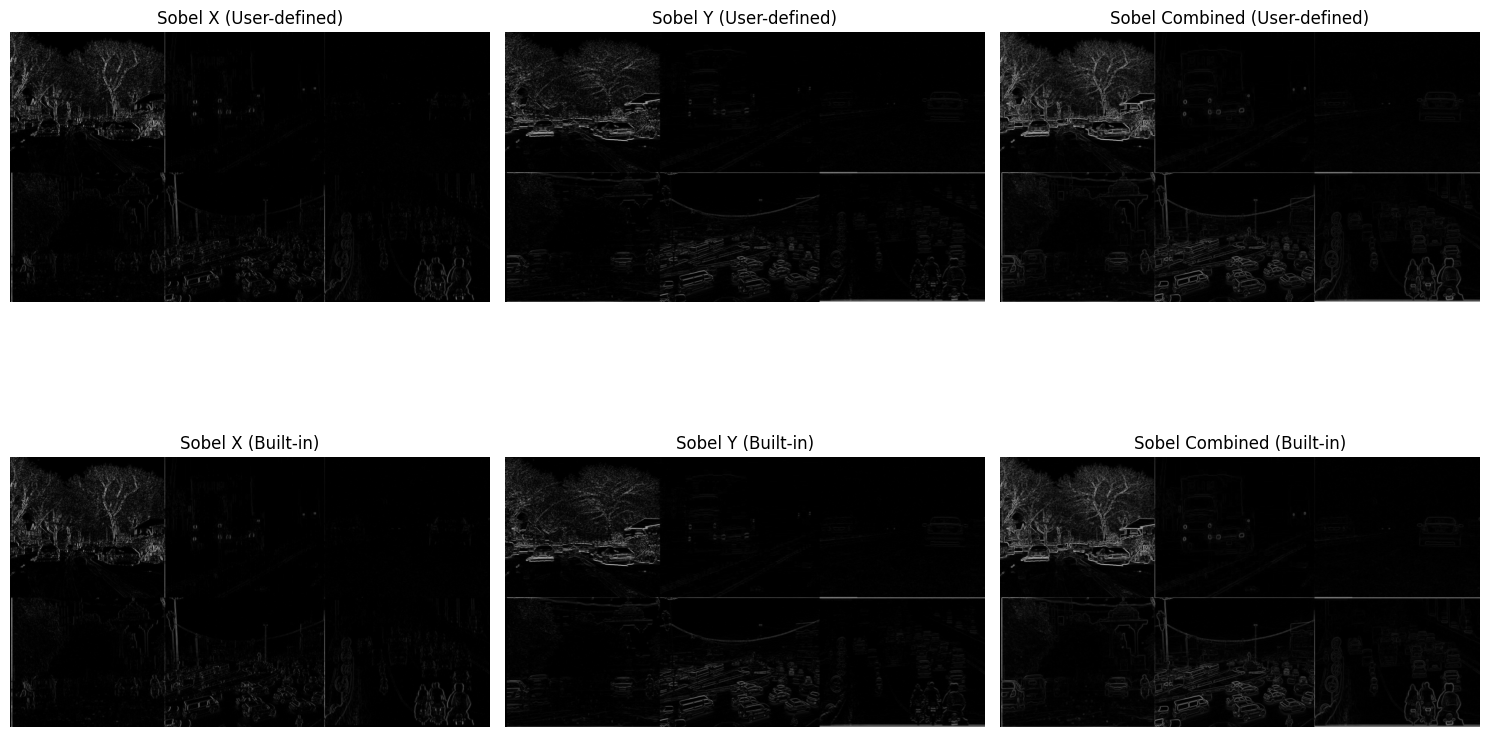

In [19]:
def sobel_edge_detection(image):
    sobel_x = np.array([[-1, 0, 1], 
                        [-2, 0, 2], 
                        [-1, 0, 1]])
    
    sobel_y = np.array([[-1, -2, -1], 
                        [0, 0, 0], 
                        [1, 2, 1]])
    
    gradient_x = ndimage.convolve(image.astype(float), sobel_x)
    gradient_y = ndimage.convolve(image.astype(float), sobel_y)
    
    gradient_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
    gradient_magnitude = (gradient_magnitude / gradient_magnitude.max() * 255).astype(np.uint8)
    
    return gradient_x, gradient_y, gradient_magnitude

sobel_x_user, sobel_y_user, sobel_combined_user = sobel_edge_detection(img)

sobel_x_builtin = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_builtin = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined_builtin = cv2.magnitude(sobel_x_builtin, sobel_y_builtin)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(np.abs(sobel_x_user), cmap='gray')
axes[0, 0].set_title('Sobel X (User-defined)')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.abs(sobel_y_user), cmap='gray')
axes[0, 1].set_title('Sobel Y (User-defined)')
axes[0, 1].axis('off')

axes[0, 2].imshow(sobel_combined_user, cmap='gray')
axes[0, 2].set_title('Sobel Combined (User-defined)')
axes[0, 2].axis('off')

axes[1, 0].imshow(np.abs(sobel_x_builtin), cmap='gray')
axes[1, 0].set_title('Sobel X (Built-in)')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.abs(sobel_y_builtin), cmap='gray')
axes[1, 1].set_title('Sobel Y (Built-in)')
axes[1, 1].axis('off')

axes[1, 2].imshow(sobel_combined_builtin, cmap='gray')
axes[1, 2].set_title('Sobel Combined (Built-in)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

**Interpretation:**
- Sobel X detects vertical edges (sides of vehicles)
- Sobel Y detects horizontal edges (top and bottom of vehicles)
- Combined Sobel shows all edges with good noise suppression
- Both user-defined and built-in methods produce similar results

## 2. Prewitt Edge Detection

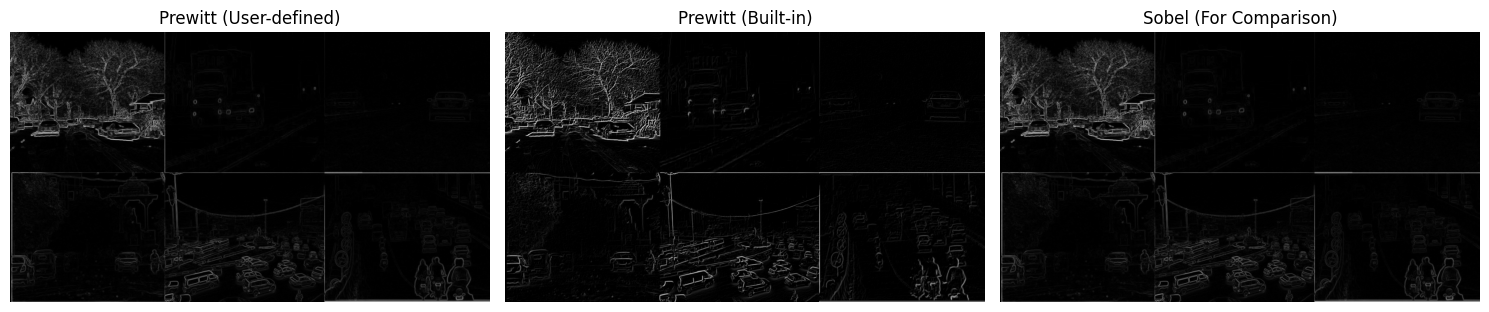

In [20]:
def prewitt_edge_detection(image):
    prewitt_x = np.array([[-1, 0, 1], 
                          [-1, 0, 1], 
                          [-1, 0, 1]])
    
    prewitt_y = np.array([[-1, -1, -1], 
                          [0, 0, 0], 
                          [1, 1, 1]])
    
    gradient_x = ndimage.convolve(image.astype(float), prewitt_x)
    gradient_y = ndimage.convolve(image.astype(float), prewitt_y)
    
    gradient_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
    gradient_magnitude = (gradient_magnitude / gradient_magnitude.max() * 255).astype(np.uint8)
    
    return gradient_magnitude

prewitt_user = prewitt_edge_detection(img)

kernelx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
kernely = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prewitt_x = cv2.filter2D(img, -1, kernelx)
prewitt_y = cv2.filter2D(img, -1, kernely)
prewitt_builtin = cv2.magnitude(prewitt_x.astype(float), prewitt_y.astype(float))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(prewitt_user, cmap='gray')
axes[0].set_title('Prewitt (User-defined)')
axes[0].axis('off')

axes[1].imshow(prewitt_builtin, cmap='gray')
axes[1].set_title('Prewitt (Built-in)')
axes[1].axis('off')

axes[2].imshow(sobel_combined_user, cmap='gray')
axes[2].set_title('Sobel (For Comparison)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Interpretation & Comparison with Sobel:**
- Prewitt uses uniform weights (1, 1, 1) while Sobel uses weighted kernel (1, 2, 1)
- Prewitt is slightly more sensitive to noise due to equal weighting


## 3. Roberts Edge Detection 

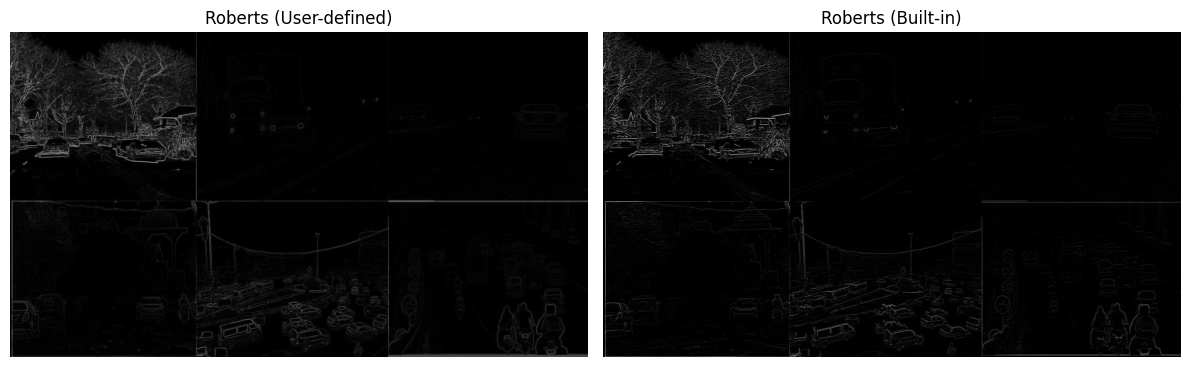

In [21]:
def roberts_edge_detection(image):
    roberts_x = np.array([[1, 0], 
                          [0, -1]])
    
    roberts_y = np.array([[0, 1], 
                          [-1, 0]])
    
    gradient_x = ndimage.convolve(image.astype(float), roberts_x)
    gradient_y = ndimage.convolve(image.astype(float), roberts_y)
    
    gradient_magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
    gradient_magnitude = (gradient_magnitude / gradient_magnitude.max() * 255).astype(np.uint8)
    
    return gradient_magnitude

roberts_user = roberts_edge_detection(img)

roberts_cross_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_cross_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
roberts_x = cv2.filter2D(img, -1, roberts_cross_x)
roberts_y = cv2.filter2D(img, -1, roberts_cross_y)
roberts_builtin = cv2.magnitude(roberts_x.astype(float), roberts_y.astype(float))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(roberts_user, cmap='gray')
axes[0].set_title('Roberts (User-defined)')
axes[0].axis('off')

axes[1].imshow(roberts_builtin, cmap='gray')
axes[1].set_title('Roberts (Built-in)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Interpretation & Limitations for Real-world Applications:**
- Roberts uses smallest kernel (2x2), making it computationally fast
- Highly sensitive to noise - produces many false edges

- **Limitations for satellite/traffic images:**
  - Cannot handle noise from weather (rain, fog, shadows)
  - Weak at detecting thick edges of large vehicles
 

## 4. Laplacian Edge Detection 

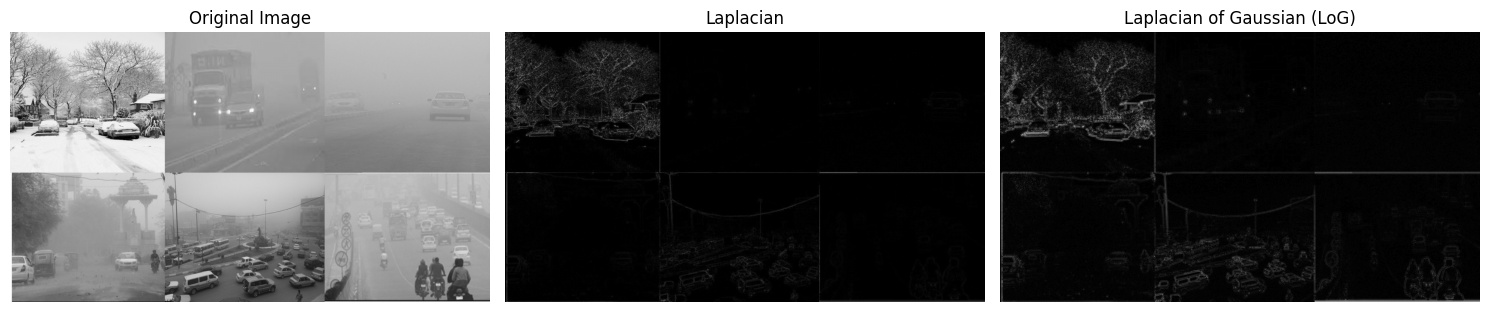

In [22]:
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian_abs = np.abs(laplacian)

img_blurred = cv2.GaussianBlur(img, (5, 5), 0)
laplacian_log = cv2.Laplacian(img_blurred, cv2.CV_64F)
laplacian_log_abs = np.abs(laplacian_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(laplacian_abs, cmap='gray')
axes[1].set_title('Laplacian')
axes[1].axis('off')

axes[2].imshow(laplacian_log_abs, cmap='gray')
axes[2].set_title('Laplacian of Gaussian (LoG)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Interpretation:**
- Laplacian detects edges in all directions simultaneously (no directional bias)
- Detects rapid intensity changes using second-order derivatives


## 5. Canny Edge Detection 

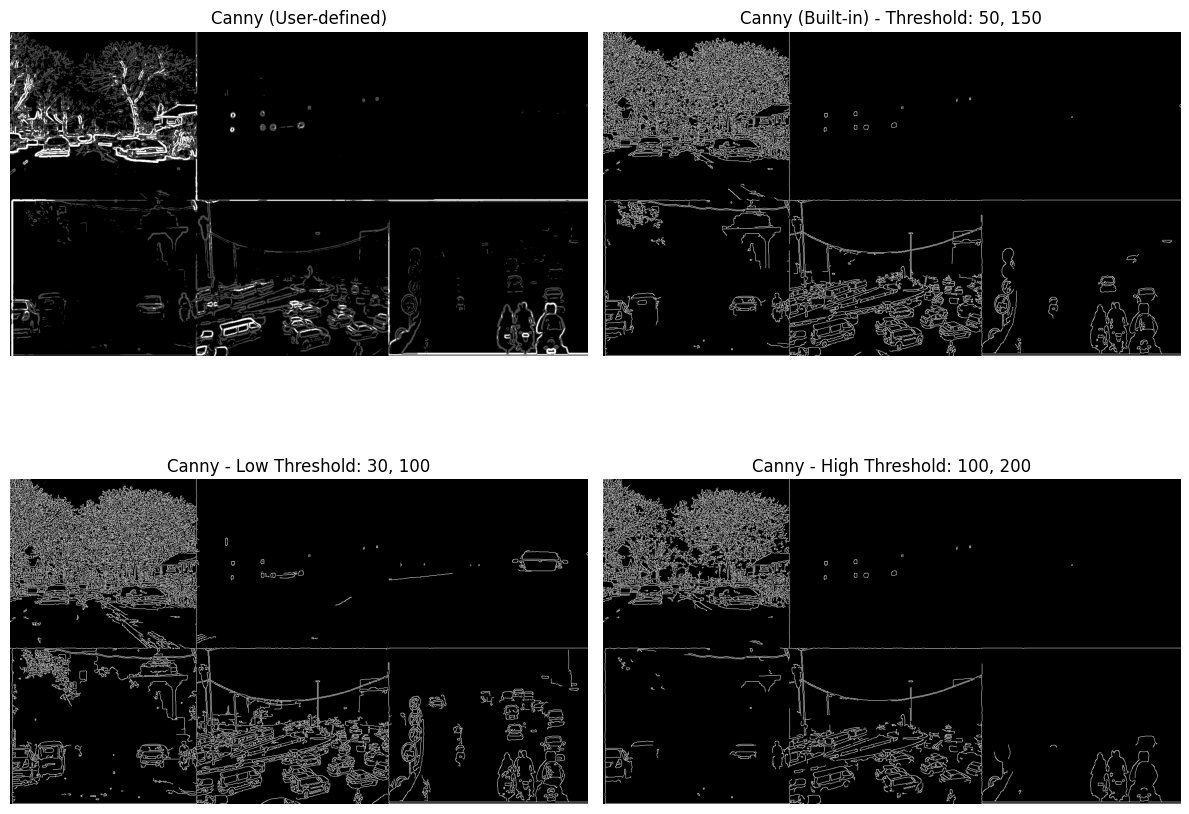

In [23]:
def canny_edge_detection(image, low_threshold=50, high_threshold=150):
    blurred = cv2.GaussianBlur(image, (5, 5), 1.4)
    
    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    gradient_direction = np.arctan2(sobel_y, sobel_x)
    
    nms = gradient_magnitude.copy()
    
    strong_edges = (gradient_magnitude > high_threshold).astype(np.uint8) * 255
    weak_edges = ((gradient_magnitude >= low_threshold) & 
                  (gradient_magnitude <= high_threshold)).astype(np.uint8) * 75
    
    edges = strong_edges + weak_edges
    
    return edges

canny_user = canny_edge_detection(img, 50, 150)

canny_builtin = cv2.Canny(img, 50, 150)

canny_low = cv2.Canny(img, 30, 100)
canny_high = cv2.Canny(img, 100, 200)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(canny_user, cmap='gray')
axes[0, 0].set_title('Canny (User-defined)')
axes[0, 0].axis('off')

axes[0, 1].imshow(canny_builtin, cmap='gray')
axes[0, 1].set_title('Canny (Built-in) - Threshold: 50, 150')
axes[0, 1].axis('off')

axes[1, 0].imshow(canny_low, cmap='gray')
axes[1, 0].set_title('Canny - Low Threshold: 30, 100')
axes[1, 0].axis('off')

axes[1, 1].imshow(canny_high, cmap='gray')
axes[1, 1].set_title('Canny - High Threshold: 100, 200')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

**Interpretation:**
- Canny provides clean, continuous, and well-localized edges
- Multi-stage process: Gaussian blur → Gradient calculation → Non-max suppression → Double thresholding → Edge tracking




### 6.  Sobel operator performs **reasonably well** under varying lighting conditions due to:
- Uses gradient-based approach that is relatively robust to uniform lighting changes
- Center-weighted kernel (1, 2, 1) provides good noise suppression
- However, it may struggle with extreme shadows or overexposed areas where contrast is lost


### 7. Prewitt operator is **moderately effective** for smooth edges but has limitations:
- Uses uniform weighting which makes it sensitive to noise from motion blur
- Can detect smooth gradual transitions in intensity
- However, more susceptible to noise compared to Sobel



### 8. Canny's multi-stage process reduces false detections through:
1. **Gaussian Blur**: Removes noise before edge detection
2. **Gradient Calculation**: Finds edge strength and direction
3. **Non-Maximum Suppression**: Thins edges to single pixels, removing weak responses




### 9. 1. **Gaussian Smoothing**: 
   - Reduces noise and smooths the image
   - Creates a scale-space representation
   - Handles motion blur by averaging pixel intensities

2. **Laplacian Detection**:
   - Detects zero-crossings (rapid intensity changes)
   - Second-order derivative is less sensitive to gradual changes




### 10. For real-time traffic monitoring, **Canny or Sobel** operators are better choices as they balance speed with accuracy and noise robustness.
